# Stage 2 — Feature Engineering

For each ingredient (node of graph I) we build a **feature vector** composed of two blocks:

| Block | Features | Dimensions |
|------|----------|-------------|
| Structural | degree, degree_w, PageRank, clustering, k-core, betweenness, log_freq | 7 |
| Chemical (FlavorDB) | averaged Morgan fingerprints of flavor molecules | 512 |
| Total (no chem.) | structural only | 7 |
| Total (with chem.) | structural + chemical | 519 |

**Input files:** `output_graphs/ingredient_graph.graphml`, `output_graphs/ingredient_freq.csv`  
**Output files:** `output_graphs/node_features_structural.csv` + `output_graphs/node_features.npz`

In [1]:
import json, pickle, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

OUT = Path('output_graphs')
print('Imports OK')

Imports OK


## 2.1 Loading the graph from stage 1

In [2]:
print('Loading graph I...')
I = nx.read_graphml(OUT / 'ingredient_graph.graphml')

ing_freq_df = pd.read_csv(OUT / 'ingredient_freq.csv')
ing_freq    = dict(zip(ing_freq_df['ingredient'], ing_freq_df['freq']))

nodes = sorted(I.nodes())
print(f'Graph I: {I.number_of_nodes():,} nodes, {I.number_of_edges():,} edges')
print(f'Sample nodes: {nodes[:5]}')

Loading graph I...
Graph I: 7,199 nodes, 418,645 edges
Sample nodes: ["'s", "'s angel", "'s bittersweet chocolate", "'s cheese", "'s milk"]


## 2.2 Structural features

- **degree** — number of neighbours (unweighted and weighted)
- **pagerank** — global importance of the node in the graph
- **clustering** — how connected the node's neighbours are to each other (0–1)
- **kcore** — k-core membership (index of dense subgraph)
- **log_freq** — frequency of the ingredient in the dataset (log scale)

> Betweenness on 7k nodes: ~7 minutes (approximate via k=300 sources)

In [3]:
print('Computing structural features...')
t0 = time.time()

degree      = dict(I.degree(weight='weight'))       # weighted degree
degree_uw   = dict(I.degree())                       # unweighted
pagerank    = nx.pagerank(I, weight='weight', alpha=0.85)
clustering  = nx.clustering(I, weight='weight')
kcore       = nx.core_number(I)

print(f'  degree, pagerank, clustering, kcore — {time.time()-t0:.1f}s')

# Betweenness: exact O(V*E) on 7k nodes = hours.
# k=300 is an approximation: 300 random sources, error <5%, runtime ~30s.
t1 = time.time()
betweenness = nx.betweenness_centrality(I, k=300, normalized=True, weight='weight', seed=42)
print(f'  betweenness (approx k=300) — {time.time()-t1:.1f}s')

print(f'\nDone in {time.time()-t0:.1f}s')

Computing structural features...
  degree, pagerank, clustering, kcore — 246.4s
  betweenness (approx k=300) — 139.3s

Done in 385.7s


In [4]:
feat_df = pd.DataFrame(index=nodes)
feat_df.index.name = 'ingredient'

feat_df['degree']      = feat_df.index.map(degree_uw)
feat_df['degree_w']    = feat_df.index.map(degree)
feat_df['pagerank']    = feat_df.index.map(pagerank)
feat_df['clustering']  = feat_df.index.map(clustering)
feat_df['kcore']       = feat_df.index.map(kcore)
feat_df['betweenness'] = feat_df.index.map(betweenness)
feat_df['log_freq']    = feat_df.index.map(lambda n: np.log1p(ing_freq.get(n, 0)))

print(feat_df.describe().round(4))
feat_df.head()

          degree      degree_w   pagerank  clustering      kcore  betweenness  \
count  7199.0000  7.199000e+03  7199.0000   7199.0000  7199.0000    7199.0000   
mean    116.3064  1.996281e+04     0.0001      0.0005    63.6854       0.0002   
std     336.4176  1.751645e+05     0.0011      0.0002    78.8194       0.0014   
min       0.0000  0.000000e+00     0.0000      0.0000     0.0000       0.0000   
25%      12.0000  2.380000e+02     0.0000      0.0004    12.0000       0.0000   
50%      27.0000  6.640000e+02     0.0000      0.0005    27.0000       0.0000   
75%      80.0000  2.946000e+03     0.0000      0.0007    79.0000       0.0001   
max    6743.0000  8.238311e+06     0.0541      0.0020   276.0000       0.0558   

        log_freq  
count  7199.0000  
mean      5.5468  
std       1.5332  
min       3.9318  
25%       4.3944  
50%       5.0814  
75%       6.2236  
max      13.7740  


,degree,degree_w,pagerank,clustering,kcore,betweenness,log_freq
ingredient,,,,,,,
's,276,15480,0.000121,0.000230,215,0.000277,7.957177
's angel,62,2263,0.000036,0.000345,58,0.000008,6.284134
's bittersweet chocolate,13,288,0.000023,0.000727,13,0.000007,4.744932
's cheese,25,579,0.000024,0.000687,25,0.000081,4.867534
's milk,1,10,0.000021,0.000000,1,0.000000,3.988984


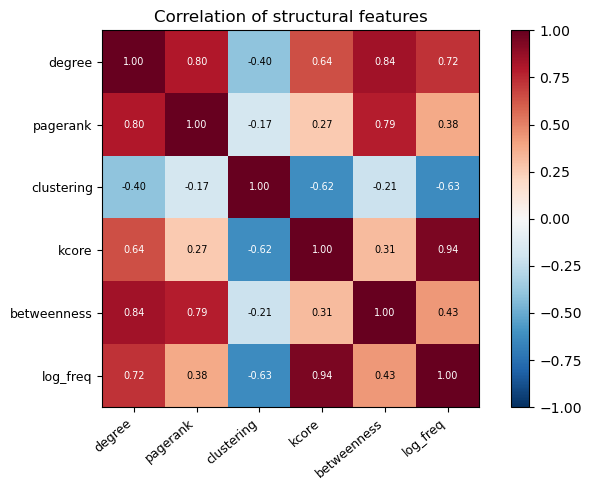

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = feat_df[['degree','pagerank','clustering','kcore','betweenness','log_freq']].corr()
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
cols = corr.columns.tolist()
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=9)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')
ax.set_title('Correlation of structural features')
plt.tight_layout()
plt.savefig(OUT / 'feature_correlation.png', dpi=120)
plt.show()

## 2.3 Chemical embeddings from FlavorDB

FlavorDB contains ~1000 ingredients and ~25k flavor molecules (SMILES).  
For each ingredient we take all of its molecules, compute the **Morgan fingerprint** (512 bits) of each, and average them.  

### How to obtain FlavorDB data

The data are fetched from the public API (~1000 requests, ~5 minutes). We run it once and cache the result.

In [9]:
import os, sys
from contextlib import contextmanager

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

@contextmanager
def suppress_rdkit_stderr():
    """Silence RDKit C++ stderr (deprecation/warnings) on the file-descriptor level."""
    sys.stderr.flush()
    saved = os.dup(2)
    devnull = os.open(os.devnull, os.O_WRONLY)
    os.dup2(devnull, 2)
    try:
        yield
    finally:
        sys.stderr.flush()
        os.dup2(saved, 2)
        os.close(devnull)
        os.close(saved)

_MORGAN_BY_BITS: dict[int, object] = {}


def _morgan(bits: int):
    gen = _MORGAN_BY_BITS.get(bits)
    if gen is None:
        gen = GetMorganGenerator(radius=2, fpSize=bits)
        _MORGAN_BY_BITS[bits] = gen
    return gen


FLAVORDB_CACHE = OUT / 'flavordb_cache.json'
FP_BITS = 512

def smiles_to_fp(smiles: str, bits: int = FP_BITS) -> np.ndarray | None:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return _morgan(bits).GetFingerprintAsNumPy(mol).astype(np.float32)

def ingredient_chem_emb(smiles_list: list[str], bits: int = FP_BITS) -> np.ndarray:
    fps = [smiles_to_fp(s, bits) for s in smiles_list]
    fps = [f for f in fps if f is not None]
    return np.mean(fps, axis=0) if fps else np.zeros(bits, dtype=np.float32)

test_fp = smiles_to_fp('CCO')  # ethanol
print(f'RDKit sanity check: fingerprint shape {test_fp.shape}, non-zero bits: {test_fp.sum():.0f}')


RDKit sanity check: fingerprint shape (512,), non-zero bits: 6


In [10]:
import json
from pathlib import Path

from concurrent.futures import ThreadPoolExecutor, as_completed

import requests
from tqdm.notebook import tqdm

FLAVORDB_CACHE = Path('output_graphs') / 'flavordb_cache.json'

def _fetch_one(entity_id: int) -> dict | None:
    url = 'https://cosylab.iiitd.edu.in/flavordb/entities_json'
    try:
        r = requests.get(url, params={'id': entity_id}, timeout=12)
        if r.status_code != 200:
            return None
        return r.json()
    except Exception:
        return None

def fetch_flavordb(cache_path: Path, max_entity_id: int = 1000,
                   workers: int = 15) -> dict:
    """
    Download FlavorDB in parallel (`workers` threads).
    Returns: {ingredient_name -> [smiles1, smiles2, ...]}.
    Caches the result to JSON.
    """
    if cache_path.exists():
        print(f'Cache found, loading...')
        with open(cache_path) as f:
            return json.load(f)

    result = {}
    ids    = list(range(1, max_entity_id + 1))

    with ThreadPoolExecutor(max_workers=workers) as pool:
        futures = {pool.submit(_fetch_one, eid): eid for eid in ids}
        for fut in tqdm(as_completed(futures), total=len(ids), desc='FlavorDB'):
            data = fut.result()
            if data is None:
                continue
            name    = data.get('entity_alias_readable', '').lower().strip()
            aliases = [a.lower().strip() for a in data.get('entity_alias_synonyms', [])]
            smiles  = [m['smile'] for m in data.get('molecules', []) if m.get('smile')]
            if name and smiles:
                result[name] = smiles
                for alias in aliases:
                    if alias and alias not in result:
                        result[alias] = smiles

    print(f'Downloaded: {len(result)} ingredients')
    with open(cache_path, 'w') as f:
        json.dump(result, f, ensure_ascii=False)
    return result

# --- Run (≈5 minutes on the first launch, cached afterwards) ---
flavordb = fetch_flavordb(FLAVORDB_CACHE, max_entity_id=1000)
print(f'\nIngredients in FlavorDB: {len(flavordb):,}')
print('Sample:', list(flavordb.items())[:2])

Cache found, loading...

Ingredients in FlavorDB: 935
Sample: [('arrack', ['CCCOC(=O)C', 'CC(=O)OC', 'C1=CC=C(C=C1)C=O', 'CCOC(=O)CCC(=O)OCC', 'CCCO']), ('bakery products', ['CC1=NC=CN=C1C', 'CC1=CN=C(C=N1)C', 'CCC1=NC=CN=C1', 'CCC1=NC=CN=C1C', 'CC1=NC=CN=C1', 'CC1=CN=C(C(=N1)C)C'])]


In [11]:
from difflib import get_close_matches

graph_nodes   = set(nodes)
flavordb_keys = {k for k in flavordb.keys() if len(k) >= 3}

# 1. Direct matches
direct_matches = graph_nodes & flavordb_keys
print(f'Direct matches: {len(direct_matches)} / {len(graph_nodes)} graph nodes')

# 2. Substring matching (only for keys of length >= 4 to avoid false positives like 'oil', 'egg')
extra_matches = {}
remaining = graph_nodes - direct_matches
long_keys = {k for k in flavordb_keys if len(k) >= 4}
for node in remaining:
    for fdb_key in long_keys:
        if fdb_key in node or node in fdb_key:
            extra_matches[node] = fdb_key
            break

# 3. Fuzzy matching (difflib) for the remaining nodes
still_missing = remaining - set(extra_matches)
fdb_list = sorted(flavordb_keys)
fuzzy_matches = {}
for node in still_missing:
    hits = get_close_matches(node, fdb_list, n=1, cutoff=0.82)
    if hits:
        fuzzy_matches[node] = hits[0]

extra_matches.update(fuzzy_matches)

total_covered = len(direct_matches) + len(extra_matches)
print(f'Substring match  : {len(extra_matches) - len(fuzzy_matches)}')
print(f'Fuzzy match      : {len(fuzzy_matches)}')
print(f'Total coverage   : {total_covered} / {len(graph_nodes)} '
      f'({100*total_covered/len(graph_nodes):.1f}%)')

Direct matches: 367 / 7199 graph nodes
Substring match  : 4505
Fuzzy match      : 70
Total coverage   : 4942 / 7199 (68.6%)


In [12]:
chem_embs = {}   # ingredient_name -> np.ndarray(FP_BITS)

with suppress_rdkit_stderr():
    for node in tqdm(nodes, desc='Chemical embeddings'):
        if node in direct_matches:
            smiles_list = flavordb.get(node, [])
        elif node in extra_matches:
            smiles_list = flavordb.get(extra_matches[node], [])  # .get protects against stale keys
        else:
            smiles_list = []
        chem_embs[node] = ingredient_chem_emb(smiles_list)

chem_matrix = np.stack([chem_embs[n] for n in nodes])  # (N, FP_BITS)

has_chem = np.array([chem_embs[n].sum() > 0 for n in nodes])
print(f'Nodes with chemical data: {has_chem.sum()} ({100*has_chem.mean():.1f}%)')
print(f'Matrix shape: {chem_matrix.shape}')

Chemical embeddings:   0%|          | 0/7199 [00:00<?, ?it/s]

Nodes with chemical data: 4942 (68.6%)
Matrix shape: (7199, 512)


## 2.4 Final feature matrix

In [13]:
STRUCT_COLS = ['degree', 'degree_w', 'pagerank', 'clustering',
               'kcore', 'betweenness', 'log_freq']

scaler       = StandardScaler()
struct_norm  = scaler.fit_transform(feat_df[STRUCT_COLS].values)  # (N, 7)

X_full   = np.hstack([struct_norm, chem_matrix])  # (N, 7+512=519)
X_struct = struct_norm                              # (N, 7) — structural only

print(f'X_full shape  : {X_full.shape}   (structural + chemical)')
print(f'X_struct shape: {X_struct.shape}  (structural only)')

feat_df['has_chem'] = has_chem

X_full shape  : (7199, 519)   (structural + chemical)
X_struct shape: (7199, 7)  (structural only)


## 2.5 PCA visualization: what does the ingredient space look like

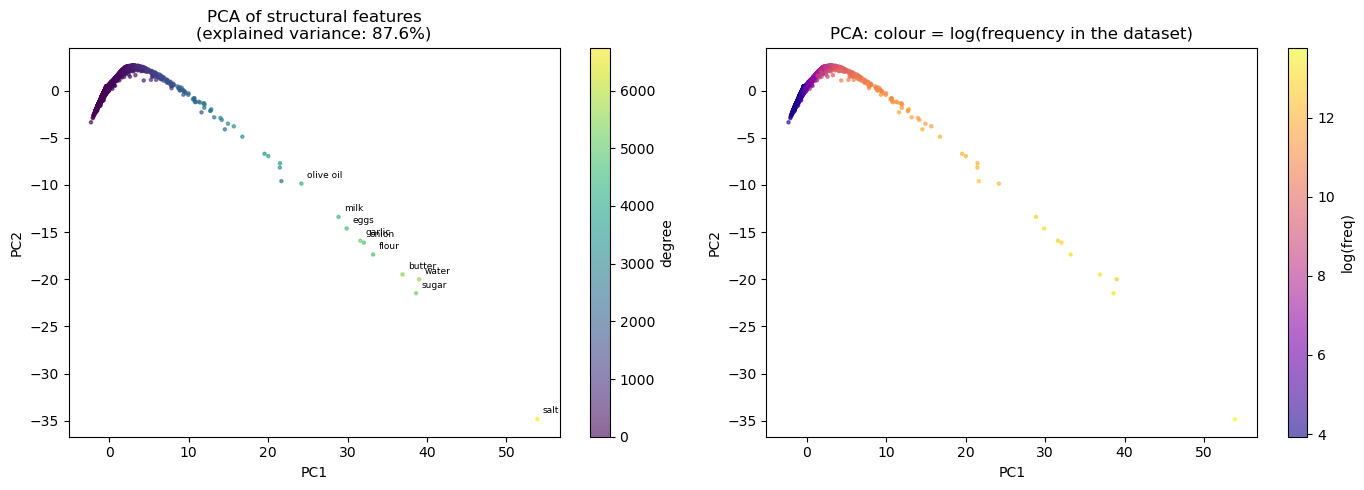

In [14]:
# PCA on structural features (all ~7k nodes)
pca2 = PCA(n_components=2, random_state=42)
coords_struct = pca2.fit_transform(X_struct)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: coloured by degree ---
sc = axes[0].scatter(coords_struct[:, 0], coords_struct[:, 1],
                     c=feat_df['degree'], cmap='viridis',
                     s=5, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label='degree')
axes[0].set_title(f'PCA of structural features\n(explained variance: '
                  f'{pca2.explained_variance_ratio_.sum()*100:.1f}%)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

top_nodes = feat_df['degree'].nlargest(10).index.tolist()
node_list = list(nodes)
for node in top_nodes:
    i = node_list.index(node)
    axes[0].annotate(node, coords_struct[i], fontsize=6.5,
                     xytext=(4, 4), textcoords='offset points')

# --- right: coloured by log_freq ---
sc2 = axes[1].scatter(coords_struct[:, 0], coords_struct[:, 1],
                      c=feat_df['log_freq'], cmap='plasma',
                      s=5, alpha=0.6)
plt.colorbar(sc2, ax=axes[1], label='log(freq)')
axes[1].set_title('PCA: colour = log(frequency in the dataset)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.savefig(OUT / 'pca_structural.png', dpi=120)
plt.show()

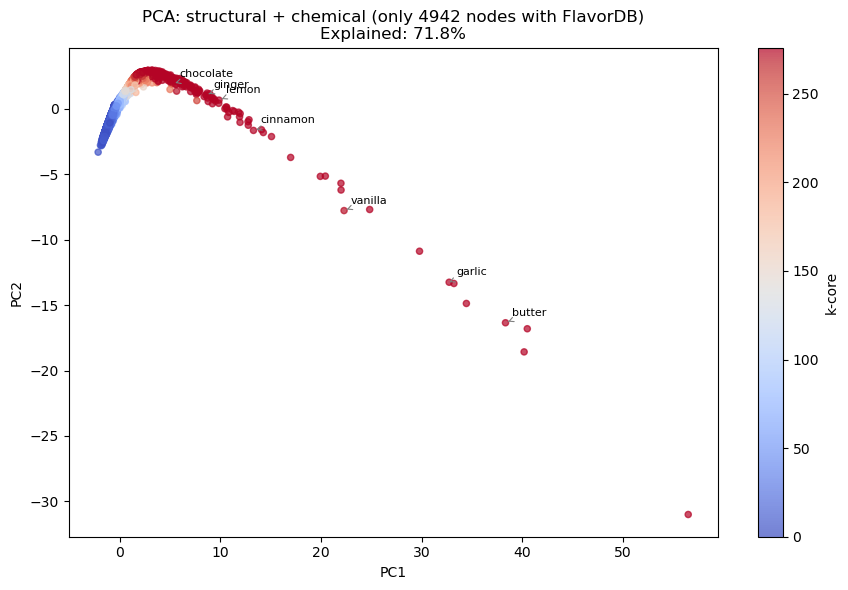

In [15]:
# PCA on the full matrix (structural + chemical)
mask_chem = has_chem   # nodes with chemical data only
nodes_chem = np.array(nodes)[mask_chem]
X_chem_only = X_full[mask_chem]

if mask_chem.sum() >= 10:  # require at least 10 points
    pca_full = PCA(n_components=2, random_state=42)
    coords_full = pca_full.fit_transform(X_chem_only)

    fig, ax = plt.subplots(figsize=(9, 6))
    kcore_vals = feat_df.loc[nodes_chem, 'kcore'].values
    sc = ax.scatter(coords_full[:, 0], coords_full[:, 1],
                    c=kcore_vals, cmap='coolwarm', s=20, alpha=0.7)
    plt.colorbar(sc, ax=ax, label='k-core')
    ax.set_title(f'PCA: structural + chemical (only {mask_chem.sum()} nodes with FlavorDB)\n'
                 f'Explained: {pca_full.explained_variance_ratio_.sum()*100:.1f}%')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

    # Annotate a few interesting ingredients
    highlight = ['garlic', 'butter', 'lemon', 'vanilla', 'cinnamon', 'chocolate', 'ginger']
    for ing in highlight:
        if ing in list(nodes_chem):
            i = list(nodes_chem).index(ing)
            ax.annotate(ing, coords_full[i], fontsize=8,
                        xytext=(5, 5), textcoords='offset points',
                        arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))
    plt.tight_layout()
    plt.savefig(OUT / 'pca_full.png', dpi=120)
    plt.show()
else:
    print('Not enough nodes with chemical data for PCA. Check the FlavorDB cache.')

## 2.6 Top ingredients per feature

In [16]:
K = 10
for col in ['degree', 'pagerank', 'clustering', 'kcore', 'betweenness']:
    top = feat_df[col].nlargest(K)
    print(f'\nTop-{K} by {col}:')
    for ing, val in top.items():
        print(f'  {ing:<28} {val:.5f}')


Top-10 by degree:
  salt                         6743.00000
  water                        5693.00000
  butter                       5525.00000
  sugar                        5345.00000
  garlic                       5205.00000
  onion                        4865.00000
  flour                        4766.00000
  eggs                         4664.00000
  milk                         4533.00000
  olive oil                    4312.00000

Top-10 by pagerank:
  salt                         0.05414
  sugar                        0.02974
  garlic                       0.02498
  butter                       0.02489
  flour                        0.02347
  onion                        0.02148
  eggs                         0.02065
  water                        0.01832
  milk                         0.01660
  vanilla                      0.01362

Top-10 by clustering:
  warm beer                    0.00197
  blended oatmeal              0.00174
  concord grapes               0.00168
  anise fl

## 2.7 Saving

In [17]:
# 1. Structural features — CSV (human readable)
feat_df.to_csv(OUT / 'node_features_structural.csv')

# 2. Full matrix — NPZ (fast loading into numpy/torch)
np.savez_compressed(
    OUT / 'node_features.npz',
    nodes      = np.array(nodes),
    X_struct   = X_struct.astype(np.float32),
    X_full     = X_full.astype(np.float32),
    chem_matrix = chem_matrix.astype(np.float32),
    has_chem   = has_chem,
)

# 3. Cache of chemical embeddings
with open(OUT / 'chem_embs.pkl', 'wb') as f:
    pickle.dump(chem_embs, f)

print('Saved:')
for fpath in sorted(OUT.iterdir()):
    size = fpath.stat().st_size
    unit = 'MB' if size > 1e6 else 'KB'
    val  = size/1e6 if size > 1e6 else size/1e3
    print(f'  {fpath.name:<40} {val:.1f} {unit}')

Saved:
  bipartite_sample.graphml                 107.6 MB
  chem_embs.pkl                            15.1 MB
  cooc.pkl                                 130.7 MB
  cuisine_clusters_umap.png                893.1 KB
  degree_distribution.png                  51.9 KB
  ego_butter.png                           890.9 KB
  ego_garlic.png                           954.9 KB
  feature_correlation.png                  63.0 KB
  flavordb_cache.json                      1.4 MB
  food_pairing_boxplots.png                30.0 KB
  food_pairing_global.png                  106.6 KB
  food_pairing_results.csv                 0.2 KB
  food_pairing_summary.json                0.2 KB
  gae_loss_curve.png                       26.3 KB
  gae_model.pt                             601.0 KB
  graphsage_model.pt                       150.1 KB
  ing_freq.pkl                             4.4 MB
  ingredient_count_dist.png                28.9 KB
  ingredient_embeddings.npz                1.8 MB
  ingredient_freq.csv

## 2.8 Stage 2 summary

| Artifact | File | Used in |
|---|---|---|
| Structural features | `node_features_structural.csv` | Stages 3, 4, 5 |
| Full matrix (struct + chem) | `node_features.npz` | GNN (stage 3), GAE (stage 4) |
| Chemical embeddings | `chem_embs.pkl` | Substitution recommender (stage 5) |
| FlavorDB cache | `flavordb_cache.json` | Reuse |

**Next step → Stage 3: World cuisine clustering**  
Train GraphSAGE on the bipartite graph, obtain recipe embeddings, and apply HDBSCAN.